In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("/Users/AlanHDLR/Desktop")

In [2]:
# Importamos y leemos la Base de Datos
data = pd.read_csv("recursos_humanos.csv")
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14993,0.76,0.83,6,293,6,0,1,0,support,low
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low


In [5]:
# Re-codificamos las variables categóricas
# Lista de columnas que quieres codificar
import pandas as pd

columnas_categoricas = ['sales', 'salary']

# Aplicamos pd.get_dummies, para las columnas categoricas
# El problema era que la tabla resulatante me mostraba valores booleanos
data_codificada = pd.get_dummies(data, columns = columnas_categoricas)

# Convertimos todas las columnas booleanas a tipo entero para que muestren valores entre 0 y 1.
# True se convierte en 1 y False se convierte en 0.
columnas_booleanas = data_codificada.select_dtypes(include=['bool']).columns
data_codificada[columnas_booleanas] = data_codificada[columnas_booleanas].astype(int)

data_codificada

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,0.76,0.83,6,293,6,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


In [7]:
# Importamos las librerias necesarias para comenzar nuestro analisis
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Verificamos que todos nuestros datos sean "int64" o "float64"
data_codificada.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales_IT                   int32
sales_RandD                int32
sales_accounting           int32
sales_hr                   int32
sales_management           int32
sales_marketing            int32
sales_product_mng          int32
sales_sales                int32
sales_support              int32
sales_technical            int32
salary_high                int32
salary_low                 int32
salary_medium              int32
dtype: object

In [11]:
# Retiramos la variable a predecir "left" (1 = Sí, 0 = No).
feature_df = data_codificada[["satisfaction_level", "last_evaluation", "number_project", "average_montly_hours", "time_spend_company", "Work_accident", 
                      "promotion_last_5years", "sales_IT", "sales_RandD", "sales_accounting", "sales_hr", "sales_management", "sales_marketing",
                      "sales_product_mng", "sales_sales", "sales_support", "sales_technical", "salary_high", "salary_low", "salary_medium",]]
x = np.array(feature_df)
x[0:5]

array([[3.80e-01, 5.30e-01, 2.00e+00, 1.57e+02, 3.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00],
       [8.00e-01, 8.60e-01, 5.00e+00, 2.62e+02, 6.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00],
       [1.10e-01, 8.80e-01, 7.00e+00, 2.72e+02, 4.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00],
       [7.20e-01, 8.70e-01, 5.00e+00, 2.23e+02, 5.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00],
       [3.70e-01, 5.20e-01, 2.00e+00, 1.59e+02, 3.00e+00, 0.00e+00,


In [13]:
data_codificada["left"] = data_codificada["left"].astype("int")
y = np.asarray(data_codificada["left"])
y[0:15]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
# Creación de grupos de entrenamiento y prueba 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 4)
print("Grupo de entrenamiento: ", x_train.shape, y_train.shape)
print("Grupo de prueba: ", x_test.shape, y_test.shape)

Grupo de entrenamiento:  (11998, 20) (11998,)
Grupo de prueba:  (3000, 20) (3000,)


# Prueba de las diferenets SVM 

In [90]:
# Seleccionamso el SVM
from sklearn import svm
clf = svm.SVC(kernel = "rbf")
clf.fit(x_train, y_train)

SVC()

In [20]:
# Predicción para la base de prueba
yhat = clf.predict(x_test)
yhat[0:5]

array([0, 0, 0, 0, 0])

In [22]:
# Creación de matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, yhat)
cm

array([[2274,    0],
       [ 685,   41]], dtype=int64)

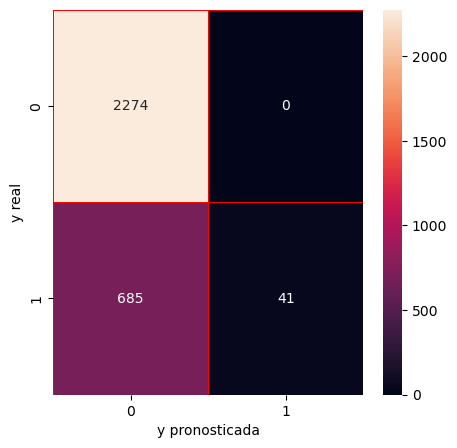

In [24]:
# Visualización de la matriz de confusion
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [26]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, yhat, labels = [0,1])
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      2274
           1       1.00      0.06      0.11       726

    accuracy                           0.77      3000
   macro avg       0.88      0.53      0.49      3000
weighted avg       0.82      0.77      0.68      3000



# Prueba de SVM con Kernel Lineal

In [96]:
clf = svm.SVC(kernel = "linear")
clf.fit(x_train, y_train)

yhat = clf.predict(x_test)

# Creación de matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, yhat)
cm

array([[2136,  138],
       [ 537,  189]], dtype=int64)

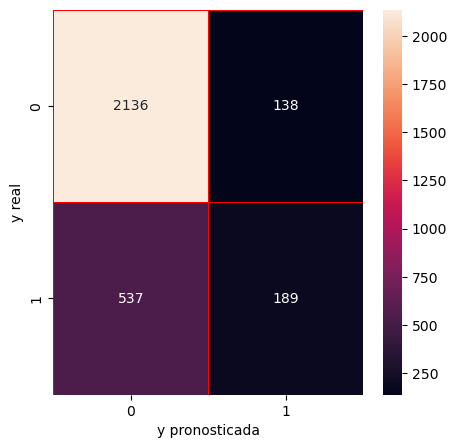

In [31]:
# Visualización de la matriz de confusion con Kernel Lineal
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [33]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, yhat, labels = [0,1])
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.80      0.94      0.86      2274
           1       0.58      0.26      0.36       726

    accuracy                           0.78      3000
   macro avg       0.69      0.60      0.61      3000
weighted avg       0.75      0.78      0.74      3000



# Prueba de SVM con Kernel Polinomial

In [102]:
clf = svm.SVC(kernel = "poly")
clf.fit(x_train, y_train)

yhat = clf.predict(x_test)

# Creación de matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, yhat)
cm

array([[2274,    0],
       [ 726,    0]], dtype=int64)

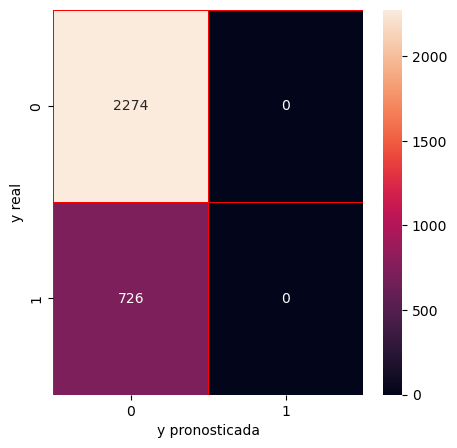

In [38]:
# Visualización de la matriz de confusion con Kernel Polinomial
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [40]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, yhat, labels = [0,1])
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      2274
           1       0.00      0.00      0.00       726

    accuracy                           0.76      3000
   macro avg       0.38      0.50      0.43      3000
weighted avg       0.57      0.76      0.65      3000



# Prueba de SVM con Kernel Sigmoide

In [108]:
clf = svm.SVC(kernel = "sigmoid")
clf.fit(x_train, y_train)

yhat = clf.predict(x_test)

# confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(x)
cm = confusion_matrix(y_test, yhat)
cm

array([[1871,  403],
       [ 503,  223]], dtype=int64)

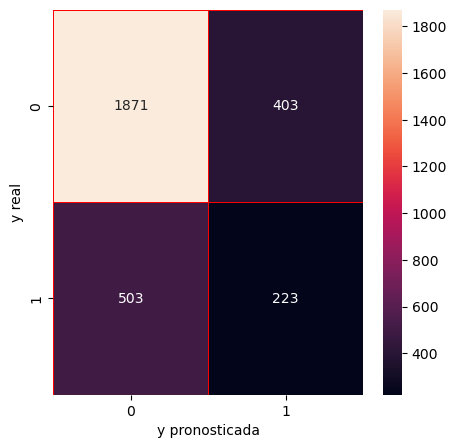

In [45]:
# Visualización de la matriz de confusion
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

# Creación de matriz de confusión
sns.heatmap(cm, annot = True, linewidths = 0.5, linecolor = "red", fmt = ".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y real")
plt.show()

In [47]:
# Estadisticas de desempeño
from sklearn.metrics import classification_report
cnf_matrix = confusion_matrix(y_test, yhat, labels = [0,1])
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2274
           1       0.36      0.31      0.33       726

    accuracy                           0.70      3000
   macro avg       0.57      0.56      0.57      3000
weighted avg       0.68      0.70      0.69      3000



In [49]:
# Insertamos el empleado con los valores preestablecidos
nuevo_empleado = {
    'satisfaction_level': 0.5,
    'last_evaluation': 0.75,
    'number_project': 4,
    'average_montly_hours': 200,
    'time_spend_company': 4,
    'Work_accident': 0,
    'promotion_last_5years': 0,
    'sales_IT': 0,                   
    'sales_RandD': 0,                
    'sales_accounting': 0,          
    'sales_hr': 0,                  
    'sales_management': 0,           
    'sales_marketing': 0,            
    'sales_product_mng': 0,          
    'sales_sales': 1,                
    'sales_support': 0,              
    'sales_technical': 0,            
    'salary_high': 0,                
    'salary_low': 0,                 
    'salary_medium': 1 
}

# Convertimos a DataFrame
df_empleado = pd.DataFrame([nuevo_empleado])

df_empleado_codificado = pd.get_dummies(df_empleado)
df_empleado_codificado = df_empleado_codificado.reindex(columns = data_codificada.drop('left', axis=1).columns, fill_value=0)

In [92]:
# Maquina Vectorial : "rbf"
prediccion = clf.predict(df_empleado_codificado)

if prediccion[0] == 1:
    print("El modelo pronostica que el empleado SE IRÁ (1)")
else:
    print("El modelo pronostica que el empleado SE QUEDA (0)")

El modelo pronostica que el empleado SE QUEDA (0)


In [94]:
puntuacion = clf.decision_function(df_empleado_codificado)
print(f"Puntaje de decisión: {puntuacion[0]}") 
# Si es positivo, predice 1. Si es negativo, predice 0.

Puntaje de decisión: -1.111077134008146


In [97]:
# Maquina Vectorial : "kernel linear
prediccion = clf.predict(df_empleado_codificado)

if prediccion[0] == 1:
    print("El modelo pronostica que el empleado SE IRÁ (1)")
else:
    print("El modelo pronostica que el empleado SE QUEDA (0)")

El modelo pronostica que el empleado SE QUEDA (0)


In [100]:
puntuacion = clf.decision_function(df_empleado_codificado)
print(f"Puntaje de decisión: {puntuacion[0]}") 
# Si es positivo, predice 1. Si es negativo, predice 0.

Puntaje de decisión: -0.70980396361365


In [104]:
# Maquina Vectorial : "Kernel Polinomial"
prediccion = clf.predict(df_empleado_codificado)

if prediccion[0] == 1:
    print("El modelo pronostica que el empleado SE IRÁ (1)")
else:
    print("El modelo pronostica que el empleado SE QUEDA (0)")

El modelo pronostica que el empleado SE QUEDA (0)


In [106]:
puntuacion = clf.decision_function(df_empleado_codificado)
print(f"Puntaje de decisión: {puntuacion[0]}") 
# Si es positivo, predice 1. Si es negativo, predice 0.

Puntaje de decisión: -0.9942983588156105


In [110]:
# Maquina Vectorial : "Kernel Sigmoide"
prediccion = clf.predict(df_empleado_codificado)

if prediccion[0] == 1:
    print("El modelo pronostica que el empleado SE IRÁ (1)")
else:
    print("El modelo pronostica que el empleado SE QUEDA (0)")

El modelo pronostica que el empleado SE QUEDA (0)


In [112]:
puntuacion = clf.decision_function(df_empleado_codificado)
print(f"Puntaje de decisión: {puntuacion[0]}") 
# Si es positivo, predice 1. Si es negativo, predice 0.

Puntaje de decisión: -20.631651939940525
